In [ ]:
# ============================================================
# Figure 1 — Empirical distribution of fitted initial conditions
# Output: pix/ic_distribution.pdf
# ============================================================
# Empirical distribution of fitted initial conditions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16,
                     'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})
bads = ["AK", "HI", "AZ"]
res = pd.concat([pd.read_csv(f) for f in glob('outputs/states/*.csv')], ignore_index=True).query("state1 not in @bads and state2 not in @bads")

S_vals = pd.concat([res['S1_0'], res['S2_0']])
I_vals = pd.concat([res['I1_0'], res['I2_0']])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(S_vals, kde=True, ax=ax1, bins=30, color='steelblue', edgecolor='white')
ax1.set_xlabel(r'$S_i(0) / N_i$', fontsize=18)
ax1.set_ylabel('Count', fontsize=18)
ax1.grid(True, alpha=0.3)

sns.histplot(np.log10(I_vals[I_vals > 0]), kde=True, ax=ax2, bins=30, color='darkorange', edgecolor='white')
ax2.set_xlabel(r'$\log_{10}(I_i(0) / N_i)$', fontsize=18)
ax2.set_ylabel('Count', fontsize=18)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pix/ic_distribution.png', dpi=150, bbox_inches='tight')
plt.savefig('pix/ic_distribution.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================
# Figure 2 — Log-likelihood vs theta: simulated (left) + real-data state pairs (right)
# Output: pix/likelihood_surface.pdf
# ============================================================
# Three regimes on one panel + real data likelihood surfaces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import flu
from src.packer import Packer
from src.objective import Objective
from src.data_loader import load_real
import us

np.random.seed(0)
thetas_sim = np.linspace(0.01, 0.09, 30)

disease = flu.Mortality
regions = ["A", "B"]
equal_pops = dict(zip(regions, [5e7, 5e7]))
different_pops = dict(zip(regions, [5e6, 1e7]))
n_season = 1
seasons = [2011 + s for s in range(n_season)]
equal_pops = {(s, r): equal_pops[r] for s in seasons for r in regions}
different_pops = {(s, r): different_pops[r] for s in seasons for r in regions}

theta = 0.05

# Identical ICs
S_id = np.full((n_season, 2), S_vals.median())
I_id = np.full((n_season, 2), I_vals.median())

# Similar ICs from empirical distribution
ind = np.random.choice(range(len(S_vals)), replace=False, size=2*n_season)
#S_sim = np.random.choice(S_vals, replace=True, size=2*n_season).reshape(-1, 2)
#I_sim = np.random.choice(I_vals, replace=True, size=2*n_season).reshape(-1, 2)
S_sim = S_vals.values[ind].reshape(-1,2)
I_sim = I_vals.values[ind].reshape(-1,2)
cases = [
    #(r'$\Delta\varphi=0$', S_id, I_id, 0, equal_pops),
    #(r'$\Delta\varphi=0$', S_sim, I_sim, 0, equal_pops),
    (r'$\Delta\varphi=\frac{\pi}{45}, N_1 = N_2$', S_sim, I_sim, 0*np.pi/45, equal_pops),
    (r'$\Delta\varphi=\pi, N_1 = N_2$', S_sim, I_sim, np.pi, equal_pops),
    # (r'$\Delta\varphi=\frac{\pi}{45}, N_1 \neq N_2$', S_sim, I_sim, np.pi/45, different_pops),
    # (r'$\Delta\varphi=\pi, N_1 \neq N_2$', S_sim, I_sim, np.pi, different_pops),
]
# choose 45 because np.pi / pairs.sort_values("phase_diff").phase_diff.median() ~ 45
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left panel: simulated
ax = axes[0]
for label, S_init, I_init, phase2, pops in cases:
    packer = Packer(disease=disease, seasons=seasons, regions=regions, populations=pops)
    true = dict(S_init=S_init, I_init=I_init, theta=theta)
    phase = np.array([0.0, phase2])
    obs = packer.sim(true, phase, disease)
    mu = obs['mu']
    obs['incidence'] = mu * disease.rho + np.random.randn(len(mu)) * np.sqrt(disease.rho * (1 - disease.rho) * mu)
    obj = Objective(obs=obs, phase=phase, disease=disease, populations=pops)
    lls = np.array([-obj(packer.pack(dict(true, theta=th))) for th in thetas_sim])
    ax.plot(thetas_sim, lls - lls.max(), label=label, linewidth=2)

ax.axvline(x=theta, color='red', linestyle='--', linewidth=2)
ax.set_xlabel(r'$\theta$', fontsize=18)
ax.set_ylabel('Log-likelihood', fontsize=18)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=16)
ax.legend(fontsize=14)






# Right panel: real data
def plot_likelihood_surface(s1, s2, ax):
    regions = [us.states.lookup(s1).name, us.states.lookup(s2).name]
    pair = f'{min(s1,s2)}x{max(s1,s2)}'
    res = pd.read_csv(f'outputs/states/{pair}.csv')
    seasons = res['season'].unique().tolist()

    obs, phase = load_real(disease=disease, regions=regions, seasons=seasons,
                           mortality_path='data/pni_mortality/excess_deaths.csv')
    pop_df = pd.read_csv('data/pni_mortality/populations.csv', parse_dates=['date'])
    pop_df['season'] = pop_df['date'].dt.year + 1
    populations = {(row['season'], row['state']): row['population']
                   for _, row in pop_df.iterrows() if row['state'] in regions}

    packer = Packer(disease=disease, seasons=seasons, regions=regions, populations=populations)
    theta_hat = res['theta'].iloc[0]
    fitted = dict(S_init=res[['S1_0', 'S2_0']].values,
                  I_init=res[['I1_0', 'I2_0']].values, 
                  theta=theta_hat)

    thetas = np.linspace(0.02, 0.499, 50)
    obj = Objective(obs=obs, phase=phase, disease=disease, populations=populations)
    lls = np.array([-obj(obj.packer.pack(dict(fitted, theta=th))) for th in thetas])
    lls = (lls - lls.max()) / (lls.max() - lls.min())

    label = f'{s1} x {s2}'
    line, = ax.plot(thetas, lls, linewidth=2, label=label)
    # Plot MLE as colored dot on the curve
    ll_at_mle = np.interp(theta_hat, thetas, lls)
    print(label, theta_hat) 
    #ax.plot(theta_hat, ll_at_mle, 'o', color=line.get_color(), markersize=10, zorder=5)

ax = axes[1]
# plot_likelihood_surface('GA', 'OH', ax=ax)
#plot_likelihood_surface('NM', 'OK', ax=ax)
#plot_likelihood_surface('OK', 'MI', ax=ax)
#plot_likelihood_surface('CA', 'NY', ax=ax)
# plot_likelihood_surface('CA', 'PA', ax=ax)
ax.set_xlabel(r'$\theta$', fontsize=18)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=16)
ax.legend(fontsize=14)

plt.tight_layout()
plt.savefig('pix/likelihood_surface.png', dpi=150, bbox_inches='tight')
plt.savefig('pix/likelihood_surface.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================
# Figure 3 [ORPHAN] — SI figure: IC-asymmetry effect (identical / similar / different)
#                     under sync vs async forcing
# Output: pix/ic_asymmetry_sync_unsync.pdf
# Status: No longer referenced from any .tex file after the IC-regime
#         comparison was dropped. Consider deleting this cell.
# ============================================================
# SI figure: Effect of IC asymmetry, sync vs unsync
import numpy as np
import matplotlib.pyplot as plt
from src import flu
from src.packer import Packer
from src.objective import Objective

N_POP = 5e6
disease = flu.Mortality
regions = ['A', 'B']
n_season = 10
seasons = list(range(n_season))
thetas_grid = np.linspace(0.02, 0.1, 40)
populations = {(s, r): N_POP for s in seasons for r in regions}
packer = Packer(disease=disease, seasons=seasons, regions=regions, populations=populations)
theta = 0.05

np.random.seed(0)

# Identical ICs
S_id = np.full((n_season, 2), 0.6)
I_id = np.full((n_season, 2), 1e-4)

# Similar ICs from empirical distribution
S_sim = S_vals.values[np.random.choice(len(S_vals), size=2*n_season, replace=True)].reshape(-1, 2)
I_sim = I_vals.values[np.random.choice(len(I_vals), size=2*n_season, replace=True)].reshape(-1, 2)

# Very different ICs
S_dif = np.column_stack([np.random.uniform(*disease.slim_different, size=n_season),
                         np.random.uniform(*disease.slim_different, size=n_season)])
I_dif = np.column_stack([np.random.uniform(*disease.ilim_different, size=n_season),
                         np.random.uniform(*disease.ilim_different, size=n_season)])

ic_cases = [
    ('Identical ICs', S_id, I_id),
    ('Similar ICs', S_sim, I_sim),
    ('Different ICs', S_dif, I_dif),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, phase2, title in [(ax1, 0, r'$\Delta\varphi = 0$'), (ax2, np.pi, r'$\Delta\varphi = \pi$')]:
    phase = np.array([0.0, phase2])
    for label, S_init, I_init in ic_cases:
        true = dict(S_init=S_init, I_init=I_init, theta=theta)
        obs = packer.sim(true, phase, disease)
        mu = obs['mu']
        np.random.seed(42)
        obs['incidence'] = mu * disease.rho + np.random.randn(len(mu)) * np.sqrt(disease.rho * (1 - disease.rho) * mu)
        obj = Objective(obs=obs, phase=phase, disease=disease, populations=populations)
        lls = np.array([-obj(packer.pack(dict(true, theta=th))) for th in thetas_grid])
        ax.plot(thetas_grid, lls - lls.max(), label=label, linewidth=2)
    ax.axvline(x=theta, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel(r'$\theta$', fontsize=18)
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=16)
    ax.set_title(title, fontsize=18)

ax1.set_ylabel('Log-likelihood', fontsize=18)
ax2.legend(fontsize=14)

plt.tight_layout()
plt.savefig('pix/ic_asymmetry_sync_unsync.png', dpi=150, bbox_inches='tight')
plt.savefig('pix/ic_asymmetry_sync_unsync.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================
# Figure 4 — theta-hat vs sqrt(CRLB) scatter with significance region,
#            all US state pairs
# Output: pix/theta_vs_crlb.pdf
# ============================================================
# Theta estimate vs CRLB std with significance regions
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from scipy.stats import norm
from src.helpers import crlb4std
threshold = norm.isf(0.05)

AKHI = ["AK", "HI", 'AZ']
res = pd.concat([pd.read_csv(f) for f in glob('outputs/states/*.csv')], ignore_index=True).query("state1 not in @AKHI and state2 not in @AKHI and season > 2011")

# Aggregate CRLB across seasons per pair
pairs = []
for (s1, s2), grp in res.groupby(['state1', 'state2']):
    pairs.append({
        'state1': s1, 
        'state2': s2,
        'theta': grp['theta'].iloc[0],
        'crlb4std': crlb4std(grp['crlb'].values)
    })
pairs = pd.DataFrame(pairs)
pairs['significant'] = pairs['theta'] > threshold * pairs['crlb4std']

fig, ax1 = plt.subplots(1, 1, figsize=(7, 6))#, gridspec_kw={'width_ratios': [1, 1]})

theta_max = 0.5
crlb_max = 0.4
t = np.linspace(0, theta_max, 100)
thr_line = t / threshold

# Shaded regions
ax1.fill_between(t, thr_line, crlb_max, color='#D5E8F0', zorder=0)
ax1.fill_between(t, 0, thr_line, color='#FDEBD0', zorder=0)
ax1.plot(t, thr_line, 'k--', linewidth=1.5, zorder=2)

# Non-significant points: black circles
nonsig = pairs[~pairs['significant']]
ax1.scatter(nonsig['theta'], nonsig['crlb4std'], alpha=0.8, s=50, color='black',
           marker='o', zorder=3)

# Significant points: red stars
sig = pairs[pairs['significant']]
ax1.scatter(sig['theta'], sig['crlb4std'], alpha=0.9, s=120, color='red',
           marker='*', zorder=4)

# Region labels
ax1.text(0.25 * theta_max, 0.75 * crlb_max, r'$H_0: \theta = 0$',
        fontsize=20, color='#2171B5', ha='center', va='center', fontstyle='italic')
ax1.text(0.75 * theta_max, 0.05 * crlb_max, r'$H_A:\theta \neq 0$',
        fontsize=20, color='#D95F02', ha='center', va='center', fontstyle='italic')

ax1.set_xlim(0, theta_max)
ax1.set_ylim(0, crlb_max)
ax1.set_xlabel(r'$\hat{\theta}$', fontsize=18)
ax1.set_ylabel(r'$\sqrt{\text{CRLB}}$', fontsize=18)
ax1.grid(True, alpha=0.3)

n_sig = sig.shape[0]
n_total = len(pairs)
print(f'{n_sig} / {n_total} significant ({n_sig/n_total:.3f})')



# sns.histplot(pairs['theta'], kde=False, ax=ax2, bins=15, color='steelblue', edgecolor='white')
# ax2.set_xlim(0, 0.5)
# ax2.set_xlabel(r'$\hat{\theta}$', fontsize=18)
# ax2.set_ylabel('Count', fontsize=18)
# ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pix/theta_vs_crlb.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/theta_vs_crlb.pdf", bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Figure 5 — Phase difference |phi1 - phi2| vs theta-hat, state-pair scatter
# Output: pix/phase_diff_vs_theta.pdf
# ============================================================
# Phase difference vs theta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from scipy.stats import norm
from src.helpers import crlb4std
from src.data_loader import estimate_phase

AKHI = ["AK", "HI" , "AZ"]
res = pd.concat([pd.read_csv(f) for f in glob('outputs/states/*.csv')], ignore_index=True).query("state1 not in @AKHI and state2 not in @AKHI and season > 2011")

# Aggregate per pair
pairs = []
for (s1, s2), grp in res.groupby(['state1', 'state2']):
    pairs.append({'state1': s1, 'state2': s2,
                  'theta': grp['theta'].iloc[0],
                  'crlb4std': crlb4std(grp['crlb'].values)})
pairs = pd.DataFrame(pairs)

# Estimate phase for each state
import us
phase_cache = {}
for abbr in set(pairs['state1']) | set(pairs['state2']):
    state = us.states.lookup(abbr)
    if state:
        phase_cache[abbr] = estimate_phase(state.name)

pairs['phase1'] = pairs['state1'].map(phase_cache)
pairs['phase2'] = pairs['state2'].map(phase_cache)
pairs['phase_diff'] = np.abs(pairs['phase1'] - pairs['phase2'])
# Wrap to [0, pi]
pairs['phase_diff'] = np.minimum(pairs['phase_diff'], 2 * np.pi - pairs['phase_diff'])

fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
ax1.scatter(pairs['phase_diff'], pairs['theta'], alpha=0.5, s=12, color='black')
ax1.set_xlabel(r'$|\varphi_1 - \varphi_2|$', fontsize=18)
ax1.set_ylabel(r'$\hat{\theta}$', fontsize=18)
ax1.set_xticks([np.pi/20, np.pi/10])
ax1.set_xticklabels([r'$\frac{\pi}{20}$', r'$\frac{\pi}{10}$'])
ax1.set_xlim(0, 3*np.pi/20)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pix/phase_diff_vs_theta.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/phase_diff_vs_theta.pdf", bbox_inches='tight')
plt.show()

pairs.sort_values("phase_diff").query("state1 != 'NM' and state2 != 'NM'")#.phase_diff.iloc[-1]

In [ ]:
# ============================================================
# Figure 6 — Quantile regression of sqrt(CRLB) on population ratio (max/min)
# Output: none (prints QuantReg summary to stdout; figure code is commented out)
# ============================================================
# Population ratio and phase difference vs z-score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from scipy.stats import norm
from src.helpers import crlb4std
from src.data_loader import estimate_phase
import us
import seaborn as sns
from scipy.stats import linregress

# from scipy.stats  import norm
# a = norm.isf(0.05)
AKHI = ["AK", "HI" , "AZ"]
CANY = ['CA','TX','FL','NY','PA','IL','OH','GA','NC','MI','NJ','VA','WA','AZ','MA','TN','IN','MD','MO','WI','CO','MN','SC','AL','LA']
#CANY = ['CA','TX','FL','NY','OH']
res = pd.concat([pd.read_csv(f) for f in glob('outputs/states/*.csv')], ignore_index=True).query("state1 not in @AKHI and state2 not in @AKHI")

# Populations
pop_df = pd.read_csv('data/pni_mortality/populations.csv', parse_dates=['date'])
pop_df['season'] = pop_df['date'].dt.year + 1
avg_pop = pop_df.groupby('state')['population'].mean()

# Phases
phase_cache = {}
for abbr in res['state1'].unique().tolist() + res['state2'].unique().tolist():
    if abbr not in phase_cache:
        state = us.states.lookup(abbr)
        if state:
            phase_cache[abbr] = estimate_phase(state.name)

# Aggregate per pair
pairs = []
for (s1, s2), grp in res.groupby(['state1', 'state2']):
    st1 = us.states.lookup(s1)
    st2 = us.states.lookup(s2)
    if st1 is None or st2 is None:
        continue
    p1 = avg_pop.get(st1.name, np.nan)
    p2 = avg_pop.get(st2.name, np.nan)
    if np.isnan(p1) or np.isnan(p2):
        continue
    pop_ratio = max(p1, p2) / min(p1, p2)
    ph1 = phase_cache.get(s1, np.nan)
    ph2 = phase_cache.get(s2, np.nan)
    phase_diff = abs(ph1 - ph2)
    phase_diff = min(phase_diff, 2 * np.pi - phase_diff)
    c = crlb4std(grp['crlb'].values)
    th = grp['theta'].iloc[0]
    pairs.append({'s1': s1,
                  's2': s2,
                  'maxmin': pop_ratio,
                  'minmax': 1/ pop_ratio,
                  'phase_diff': phase_diff,
                  'crlb': c,
                  'z': th / c if c > 0 else np.nan})

pairs = pd.DataFrame(pairs).dropna()#.query("pop_ratio > 0.5")
#mins = pairs.groupby("pop_ratio").crlb.min()

#plt.scatter(pairs[v], pairs['crlb'])
#plt.xlabel("max pop /  min pop")
#plt.ylabel("CRLB")
#plt.xlim(0,0.2)
#plt.ylim(0,0.2)
#plt.scatter(mins.index, mins.values)
# ax = sns.scatterplot(data=pairs, x=v, y='crlb')
# ax.set(xlabel=r"$\frac{\max(N_1,N_2)}{\min(N_1,N_2)}$", ylabel=r"$\sqrt{\mathrm{CRLB}}$", ylim=(0,0.2))
# plt.tight_layout()
# plt.savefig('pix/popratio_vs_crlb.png', dpi=150, bbox_inches='tight')
# plt.savefig('pix/popratio_vs_crlb.pdf', bbox_inches='tight')
# plt.show()

# slope, intercept, r, p, se = linregress(pairs[v], pairs['crlb'])
# print(f"Slope={slope:.4f}, p={p:.4f}, r²={r**2:.4f}")

import statsmodels.api as sm
mod = sm.QuantReg(pairs['crlb'], sm.add_constant(pairs['maxmin']))
res = mod.fit(q=0.05)                                                                           
print(res.summary())

In [ ]:
# ============================================================
# Figure 7 — OLS regression of sqrt(CRLB) on 1/population-ratio (min/max)
# Output: none (prints OLS summary to stdout)
# Depends on `pairs` DataFrame produced in Figure 6
# ============================================================
import statsmodels.api as sm
X = sm.add_constant(pairs[['minmax']])
model = sm.OLS(pairs['crlb'], X).fit()
print(model.summary())                               

In [ ]:
# ============================================================
# Figure 8 — Absolute humidity time series: Arizona vs New York
# Output: pix/abs_hum.pdf
# ============================================================
# Absolute humidity for Arizona, Oklahoma, and Texas
import pandas as pd
import matplotlib.pyplot as plt

ppairs = [('Arizona', 'C0'), ('New_York', 'C2')]
fig, axes = plt.subplots(len(ppairs), 1, figsize=(12, 5))

axes[0].set_xticks([])
axes[0].set_ylabel('Abs. Hum. (AZ)', fontsize=18)
axes[1].set_ylabel('Abs. Hum. (NY)', fontsize=18)
for (state, color), ax in zip(ppairs, axes):
    df = pd.read_csv(f'data/viboud/{state}.csv', parse_dates=['time'])
    ax.plot(df['time'], df['AH'], linewidth=0.8, color=color, label=state)
    
    ax.set_yticks([])

ax.set_xlabel('Date', fontsize=18)

plt.tight_layout()
plt.savefig('pix/abs_hum.png', dpi=150, bbox_inches='tight')
plt.savefig('pix/abs_hum.pdf', bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================
# Figure 9 — Raw weekly P&I death counts, four representative states
# Output: pix/raw_deaths.pdf
# ============================================================
# Cell 3: Raw P&I Death Counts for Representative States
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/pni_mortality/deaths.csv", parse_dates=["date"])
states = ["California", "New York", "Texas", "Florida"]
df = df[df["state"].isin(states)].sort_values("date")

fig, ax = plt.subplots(1, 1, figsize=(12, 8), sharex=True)
for state in states:
    dd = df[df["state"] == state]
    ax.plot(dd["date"], dd["deaths"], linewidth=0.8, label=state)
ax.set_ylabel("Deaths", fontsize=18)
ax.set_xlabel("Date", fontsize=18)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=14)
plt.tight_layout()
plt.savefig("pix/raw_deaths.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/raw_deaths.pdf", bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Figure 10 — Weekly P&I deaths with flu seasons highlighted (4 states)
# Output: pix/seasons_highlighted.pdf
# ============================================================
# P&I Deaths with flu seasons highlighted
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.flu import Mortality as flu

df = pd.read_csv("data/pni_mortality/deaths.csv", parse_dates=["date"])
states = ["California", "New York", "Texas", "Florida"]
colors = {"California": "C0", "New York": "C1", "Texas": "C2", "Florida": "C3"}
seasons = list(range(2011, 2019)) + [2023, 2024, 2025]
n_weeks = flu.n_weeks

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

for ax, state in zip(axes, states):
    dd = df[df["state"] == state].sort_values("date")
    c = colors[state]

    # Full time series: light, transparent
    ax.plot(dd["date"], dd["deaths"], color=c, linewidth=0.8, alpha=0.25)

    # Flu seasons: dark, opaque
    for s_idx, season in enumerate(seasons):
        start = pd.Timestamp(year=season - 1, month=11, day=1)
        end = start + pd.Timedelta(weeks=n_weeks)
        mask = (dd["date"] >= start) & (dd["date"] < end)
        ss = dd[mask]
        if not ss.empty:
            ax.plot(ss["date"], ss["deaths"], color=c, linewidth=1.2, alpha=0.9,
                    label=state if s_idx == 0 else None)

    ax.set_ylim(0, dd["deaths"].max() / 3)
    ax.set_ylabel(state, fontsize=14)
    ax.legend(loc='upper right', fontsize=12)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date", fontsize=16)
plt.tight_layout()
plt.savefig("pix/seasons_highlighted.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/seasons_highlighted.pdf", bbox_inches='tight')
plt.show()

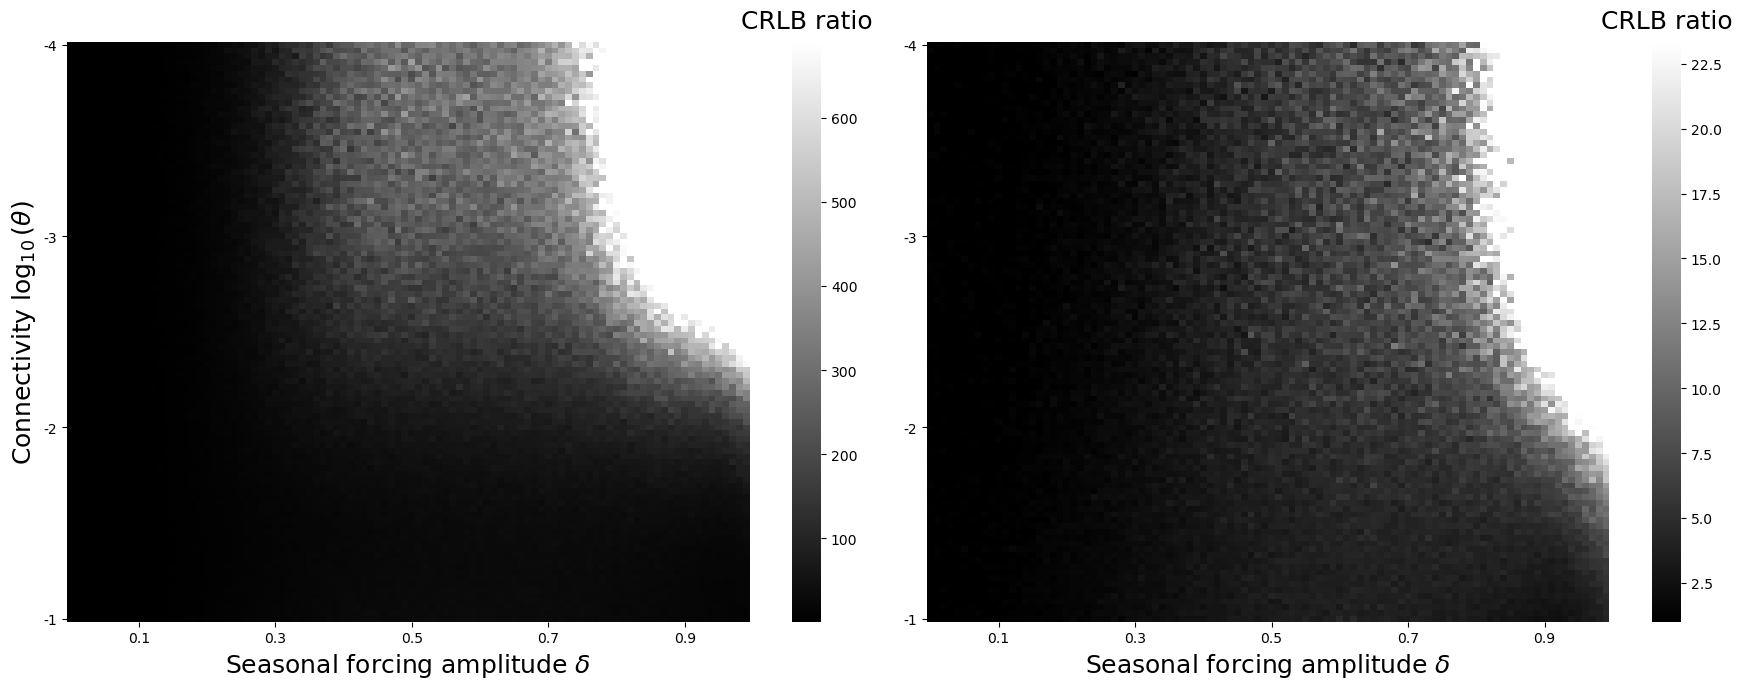

In [3]:
# ============================================================
# Figure 11 — CRLB ratio heatmap (sync / async) over (theta, delta).
#             Single panel when outputs/crlb.csv has no `ic_regime`
#             column; falls back to two-panel similar/different otherwise.
# Output: pix/crlb_ratio.pdf
# ============================================================
# CRLB Ratio Heatmap (sync / unsync) — two panels: similar vs different ICs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed

def median_ratio(pp):
    sync = pp.query("phase2 == 0").crlb.values
    unsync = pp.query("phase2 > 0").crlb.values
    if len(sync) == 0 or len(unsync) == 0:
        return np.nan
    return np.median(sync) / np.median(unsync)

df = pd.read_csv("outputs/crlb.csv")
df = df.rename(columns={'delta': 'amplitude'})

has_regimes = 'ic_regime' in df.columns
regimes = ['similar', 'different'] if has_regimes else ['all']

# Compute heatmaps for each regime
heats = {}
for regime in regimes:
    sub = df[df['ic_regime'] == regime] if has_regimes else df
    groups = list(sub.groupby(['amplitude', 'theta']))
    results = Parallel(n_jobs=-1)(delayed(median_ratio)(group) for name, group in groups)
    index = pd.MultiIndex.from_tuples([name for name, group in groups], names=['amplitude', 'theta'])
    agg = pd.Series(results, index=index)
    heat = agg.unstack(level='amplitude')
    heat.index = np.log10(heat.index)
    heats[regime] = heat

if has_regimes and len(regimes) == 2:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    axes = [ax1, ax2]
    titles = ['Similar ICs', 'Different ICs']
else:
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))
    axes = [ax1]
    titles = ['']

for ax, regime, title in zip(axes, regimes, titles):
    heat = heats[regime]
    amplitudes = heat.columns.values
    thetas = heat.index.values
    vals = heat.values[np.isfinite(heat.values)]
    vmax = np.percentile(vals, 90)

    hm = sns.heatmap(heat, cmap='grey', xticklabels=False, yticklabels=False,
                     vmin=1, vmax=vmax, ax=ax, cbar=True, cbar_kws={})

    # Place colorbar label on top so it's not confused with y-axis
    cbar = hm.collections[0].colorbar
    cbar.ax.set_title('CRLB ratio', fontsize=18, pad=10)

    x_desired = [0.1, 0.3, 0.5, 0.7, 0.9]
    x_positions = [np.argmin(np.abs(amplitudes - x)) + 0.5 for x in x_desired]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_desired)
    y_desired = [-1, -2, -3, -4]
    y_positions = [np.argmin(np.abs(thetas - y)) + 0.5 for y in y_desired]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_desired)
    ax.set_xlabel(r'Seasonal forcing amplitude $\delta$', fontsize=18)
    #ax.set_title(title, fontsize=18)
    ax.set_ylabel('')

axes[0].set_ylabel(r'Connectivity $\log_{10}(\theta)$', fontsize=18)

plt.tight_layout()
plt.savefig("pix/crlb_ratio.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/crlb_ratio.pdf", bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Figure 12 — Power heatmap (sync vs async), one row per IC regime if present
# Output: pix/power.pdf (or pix/power_{regime}.pdf if ic_regime present)
# ============================================================
# Cell 0: Power Heatmap (sync vs async) — one row per IC regime if available
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16,
                     'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})

df = pd.read_csv("outputs/crlb.csv", index_col=None)
df = df.rename(columns={'delta': 'amplitude'})
df['phase2'] = df.phase2.replace({np.pi: 'reverse-phase', 0: 'in-phase'})
df['log_crlb'] = np.log10(df.crlb)
df['log_theta'] = np.log10(df.theta)

z_alpha = 1.645
df['power'] = 1 - norm.cdf(z_alpha - df['theta'] / np.sqrt(df['crlb']))

# If ic_regime column exists, make separate figures; otherwise single figure
has_regimes = 'ic_regime' in df.columns
regimes = df['ic_regime'].unique() if has_regimes else ['all']

def draw_heatmap(data, **kwargs):
    pivot = data.pivot(index='theta', columns='amplitude', values='power')
    thetas = pivot.index.values
    amplitudes = pivot.columns.values
    ax = plt.gca()
    sns.heatmap(pivot, ax=ax, cmap='gray_r', vmin=0, vmax=1, cbar=False,
                xticklabels=False, yticklabels=False)
    ax.invert_yaxis()
    x_desired = [0.1, 0.3, 0.5, 0.7, 0.9]
    x_positions = [np.argmin(np.abs(amplitudes - x)) + 0.5 for x in x_desired]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_desired)
    y_desired_theta = [0.1, 0.01, 0.001, 0.0001]
    y_positions = [np.argmin(np.abs(thetas - y)) + 0.5 for y in y_desired_theta]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(['-1', '-2', '-3', '-4'])

for regime in regimes:
    sub = df[df['ic_regime'] == regime] if has_regimes else df
    df_agg = sub.groupby(['theta', 'amplitude', 'phase2'])['power'].mean().reset_index()

    g = sns.FacetGrid(df_agg, col='phase2', height=5, aspect=1)
    g.map_dataframe(draw_heatmap)
    g.set_axis_labels('Amplitude', r'$\log_{10}(\theta)$')
    g.set_titles(col_template='{col_name}')
    sm = plt.cm.ScalarMappable(cmap='gray_r', norm=plt.Normalize(0, 1))
    sm.set_array([])
    g.figure.colorbar(sm, ax=g.axes, location='right', shrink=0.8, label='Power')
    suffix = f"_{regime}" if has_regimes else ""
    plt.savefig(f"pix/power{suffix}.png", dpi=150, bbox_inches='tight')
    plt.savefig(f"pix/power{suffix}.pdf", bbox_inches='tight')
    if has_regimes:
        g.figure.suptitle(f"ICs: {regime}", fontsize=18, y=1.02)
    plt.show()

In [ ]:
# ============================================================
# Figure 13 [STALE — OVERWRITES Figure 2] — Old two-panel profile-likelihood
#    surface (left: similar ICs, right: different ICs), scanning four phases.
# Output: pix/likelihood_surface.pdf  <-- COLLIDES with Figure 2's output.
# Status: Predates the restructure to empirical ICs and the Figure-2 layout.
#         If run after Figure 2, it overwrites the file Figure 2 produced.
#         Consider deleting this cell.
# ============================================================
# Cell 2: Profile Likelihood Surface — two panels
# Left: similar ICs. Right: different ICs.
# Both sweep over the same four phase differences.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import flu
from src.packer import Packer
from src.objective import Objective

N_POP = 1e7
disease = flu.Mortality
regions = ["A", "B"]
n_season = 1
seasons = list(range(n_season))
thetas = np.linspace(0.02, 0.1, 40)
populations = {(s, r): N_POP for s in seasons for r in regions}
packer = Packer(disease=disease, seasons=seasons, regions=regions, populations=populations)
theta = 0.05

np.random.seed(0)

# Similar ICs: drawn from narrow ranges independently
S_sim = np.column_stack([np.random.uniform(*disease.slim_similar, size=n_season),
                         np.random.uniform(*disease.slim_similar, size=n_season)])
I_sim = np.column_stack([np.random.uniform(*disease.ilim_similar, size=n_season),
                         np.random.uniform(*disease.ilim_similar, size=n_season)])

# Different ICs: drawn from wide ranges independently
S_dif = np.column_stack([np.random.uniform(*disease.slim_different, size=n_season),
                         np.random.uniform(*disease.slim_different, size=n_season)])
I_dif = np.column_stack([np.random.uniform(*disease.ilim_different, size=n_season),
                         np.random.uniform(*disease.ilim_different, size=n_season)])

phases = [0, np.pi/10, np.pi/2, np.pi]
labels = [r"$\varphi_1-\varphi_2=0$", r"$\varphi_1-\varphi_2=\frac{\pi}{10}$",
          r"$\varphi_1-\varphi_2 = \frac{\pi}{2}$", r"$\varphi_1-\varphi_2= \pi$"]

panels = [
    (S_sim, I_sim),
    (S_dif, I_dif),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for ax, (S_init, I_init) in zip([ax1, ax2], panels):
    true = dict(S_init=S_init, I_init=I_init, theta=theta)

    for phase2, label in zip(phases, labels):
        phase = np.array([0.0, phase2])
        obs = packer.sim(true, phase, disease)
        mu = obs['mu']
        np.random.seed(42)
        obs['incidence'] = mu * disease.rho + np.random.randn(len(mu)) * np.sqrt(disease.rho * (1 - disease.rho) * mu)
        obj = Objective(obs=obs, phase=phase, disease=disease, populations=populations)
        lls = np.array([-obj(packer.pack(dict(true, theta=th))) for th in thetas])
        ax.plot(thetas, lls - lls.max(), label=label)

    ax.axvline(x=theta, color='red', linestyle='--', linewidth=2)
    ax.annotate(rf'True $\theta$', xy=(theta, 0), xycoords=('data', 'axes fraction'),
                xytext=(0, -22), textcoords='offset points',
                ha='center', va='top', fontsize=14, color='red')
    ax.set_xlabel(r"$\theta$", fontsize=18)
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=16)

ax1.set_ylabel("Log-likelihood", fontsize=18)
ax2.legend(fontsize=16)

plt.tight_layout()
plt.savefig("pix/likelihood_surface.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/likelihood_surface.pdf", bbox_inches='tight')
plt.show()